In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
# Set the compute device and define all training hyperparameters in one place
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128       # Number of images processed per training step
LEARNING_RATE = 1e-3   # Step size for gradient descent (Adam optimizer)
EPOCHS = 20            # Total number of passes over the full training dataset
HIDDEN_DIM = 512       # Number of neurons in the compressed bottleneck layer
INPUT_DIM = 3072       # 32 x 32 x 3 = 3072 (flattened CIFAR-10 image size)
SPARSITY_LAMBDA = 1e-4 # Weight of the sparsity penalty term in the total loss

print(f"Using device: {device}")

Using device: cuda


In [6]:
# Download CIFAR-10 and apply normalization; flatten is handled inside the model
transform = transforms.Compose([
    transforms.ToTensor(),                        # Converts PIL image (0-255) to tensor (0.0-1.0)
    transforms.Normalize((0.5, 0.5, 0.5),         # Subtract mean 0.5 from each RGB channel
                         (0.5, 0.5, 0.5))          # Divide by std 0.5 → pixel range becomes [-1, 1]
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:56<00:00, 3.04MB/s]
C:\Users\adity\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples : 50000
Test samples     : 10000


In [7]:
# Define the Sparse Autoencoder with an encoder, bottleneck, and decoder
class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=512):
        super(SparseAutoencoder, self).__init__()

        # Encoder: compresses input from 3072 → hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),   # Fully connected layer: 3072 → 1024
            nn.ReLU(),                     # Non-linearity; also naturally induces sparsity (zeros out negatives)
            nn.Linear(1024, hidden_dim),  # 1024 → 512 (bottleneck)
            nn.ReLU()                      # Activation at bottleneck
        )

        # Decoder: reconstructs input from hidden_dim → 3072
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),  # 512 → 1024
            nn.ReLU(),
            nn.Linear(1024, input_dim),   # 1024 → 3072 (back to original size)
            nn.Tanh()                      # Output range [-1, 1] to match normalized input
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)    # Flatten: (batch, 3, 32, 32) → (batch, 3072)
        encoded = self.encoder(x)     # Compressed representation
        decoded = self.decoder(encoded)
        return encoded, decoded

model = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
print(model)

SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=3072, bias=True)
    (3): Tanh()
  )
)


In [8]:
# Define reconstruction loss (MSE) and an L1 sparsity penalty on encoder activations
def sparse_loss(encoded, decoded, original, sparsity_lambda=SPARSITY_LAMBDA):
    # Reconstruction loss: how well the decoder rebuilds the original input
    original_flat = original.view(original.size(0), -1)   # Flatten ground truth to (batch, 3072)
    recon_loss = nn.MSELoss()(decoded, original_flat)       # Mean Squared Error between output and input

    # Sparsity loss: L1 norm of encoder activations — penalizes large/many active neurons
    sparsity_penalty = torch.mean(torch.abs(encoded))       # Mean absolute activation value

    # Total loss = reconstruction quality + sparsity regularization
    total_loss = recon_loss + sparsity_lambda * sparsity_penalty
    return total_loss, recon_loss, sparsity_penalty

In [9]:
# Set up the Adam optimizer to update model weights during training
optimizer = optim.Adam(
    model.parameters(),   # All learnable parameters (weights + biases) in the model
    lr=LEARNING_RATE       # Learning rate: controls how large each weight update is
)

In [10]:
# Train the sparse autoencoder epoch by epoch and track losses
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()            # Set model to training mode (enables dropout/batchnorm if used)
    epoch_loss = 0.0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)          # Move batch to GPU/CPU
        optimizer.zero_grad()               # Clear gradients from previous step

        encoded, decoded = model(images)    # Forward pass: get bottleneck + reconstruction

        loss, recon, sparse = sparse_loss(encoded, decoded, images)  # Compute total loss

        loss.backward()        # Backpropagate: compute gradients of loss w.r.t. all parameters
        optimizer.step()       # Update weights using computed gradients

        epoch_loss += loss.item()   # Accumulate loss for this epoch

    avg_loss = epoch_loss / len(train_loader)   # Average loss per batch
    train_losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}]  Total Loss: {avg_loss:.5f}  "
              f"Recon: {recon.item():.5f}  Sparsity: {sparse.item():.5f}")

Epoch [01/20]  Total Loss: 0.06093  Recon: 0.03777  Sparsity: 0.51186
Epoch [05/20]  Total Loss: 0.02436  Recon: 0.02364  Sparsity: 0.59933
Epoch [10/20]  Total Loss: 0.02052  Recon: 0.01797  Sparsity: 0.57163
Epoch [15/20]  Total Loss: 0.01948  Recon: 0.02022  Sparsity: 0.56373
Epoch [20/20]  Total Loss: 0.01902  Recon: 0.01763  Sparsity: 0.52715


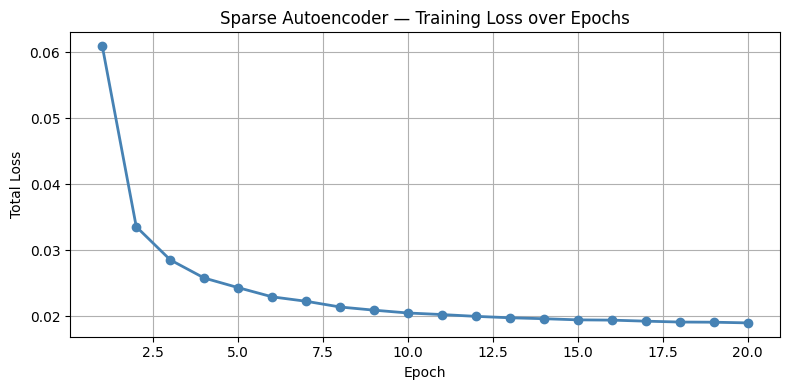

In [11]:
# Visualize how the training loss decreased over epochs
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='steelblue', linewidth=2)
plt.title("Sparse Autoencoder — Training Loss over Epochs")
plt.xlabel("Epoch")       # X-axis: each training pass over the full dataset
plt.ylabel("Total Loss")  # Y-axis: MSE + sparsity penalty value
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Compute average reconstruction loss on the unseen test dataset
model.eval()   # Switch to evaluation mode (disables dropout/batchnorm)
test_recon_loss = 0.0

with torch.no_grad():   # Disable gradient computation to save memory during inference
    for images, _ in test_loader:
        images = images.to(device)
        encoded, decoded = model(images)
        _, recon, _ = sparse_loss(encoded, decoded, images)
        test_recon_loss += recon.item()

avg_test_loss = test_recon_loss / len(test_loader)
print(f"Average Reconstruction Loss on Test Set: {avg_test_loss:.5f}")

Average Reconstruction Loss on Test Set: 0.01942


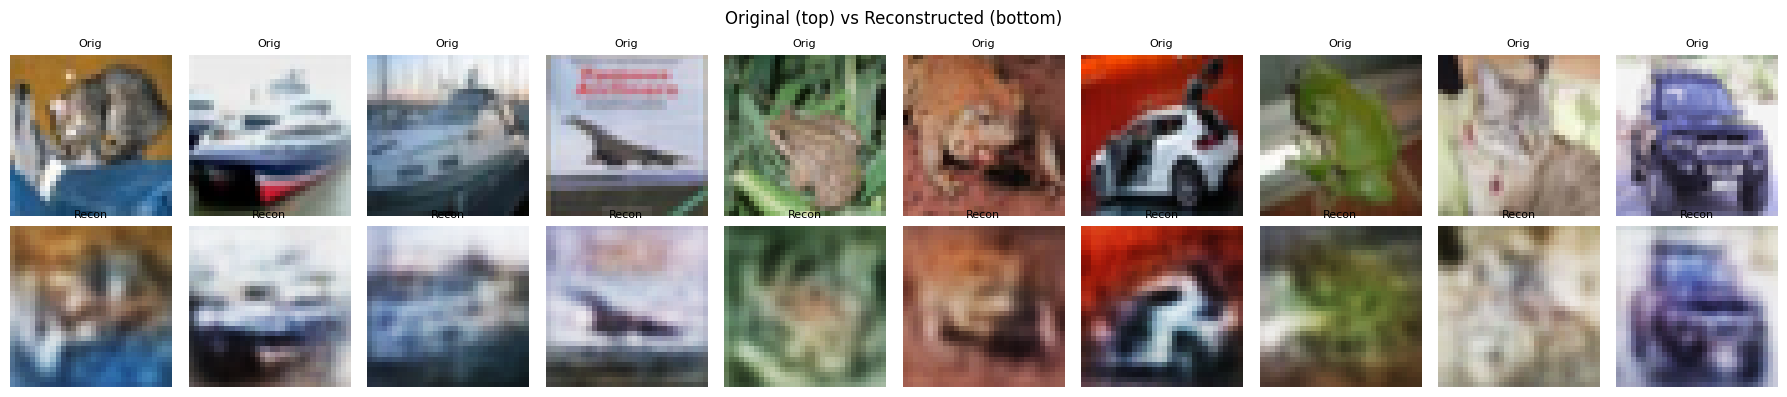

In [13]:
# Display a grid of original CIFAR-10 images alongside their autoencoder reconstructions
def denormalize(tensor):
    # Reverse the normalization: [-1,1] → [0,1] for display
    return tensor * 0.5 + 0.5

model.eval()
sample_images, _ = next(iter(test_loader))   # Grab one batch from test set
sample_images = sample_images[:10].to(device)  # Take first 10 images

with torch.no_grad():
    _, reconstructed = model(sample_images)

# Reshape flat reconstructions back to image format (batch, 3, 32, 32)
reconstructed = reconstructed.view(-1, 3, 32, 32).cpu()
sample_images_cpu = sample_images.cpu()

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    # Top row: original images
    orig = denormalize(sample_images_cpu[i]).permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    orig = np.clip(orig, 0, 1)
    axes[0, i].imshow(orig)
    axes[0, i].axis('off')
    axes[0, i].set_title("Orig", fontsize=8)

    # Bottom row: reconstructed images
    recon = denormalize(reconstructed[i]).permute(1, 2, 0).numpy()
    recon = np.clip(recon, 0, 1)
    axes[1, i].imshow(recon)
    axes[1, i].axis('off')
    axes[1, i].set_title("Recon", fontsize=8)

plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Compare reconstruction quality across three different sparsity regularization strengths
sparsity_values = [0.0, 1e-4, 1e-2]   # No sparsity | mild sparsity | strong sparsity
results = {}

for sp_lambda in sparsity_values:
    print(f"\nTraining with sparsity_lambda = {sp_lambda}")

    exp_model = SparseAutoencoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM).to(device)
    exp_optimizer = optim.Adam(exp_model.parameters(), lr=LEARNING_RATE)

    for epoch in range(1, 11):   # Shorter run: 10 epochs per experiment
        exp_model.train()
        for images, _ in train_loader:
            images = images.to(device)
            exp_optimizer.zero_grad()
            encoded, decoded = exp_model(images)
            loss, _, _ = sparse_loss(encoded, decoded, images, sparsity_lambda=sp_lambda)
            loss.backward()
            exp_optimizer.step()

    # Evaluate on test set
    exp_model.eval()
    total_recon = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            encoded, decoded = exp_model(images)
            _, recon, _ = sparse_loss(encoded, decoded, images, sparsity_lambda=sp_lambda)
            total_recon += recon.item()

    avg_recon = total_recon / len(test_loader)
    results[sp_lambda] = avg_recon
    print(f"  → Test Reconstruction Loss: {avg_recon:.5f}")

print("\n--- Summary ---")
for k, v in results.items():
    print(f"  sparsity_lambda={k:6} → Recon Loss = {v:.5f}")


Training with sparsity_lambda = 0.0
  → Test Reconstruction Loss: 0.02126

Training with sparsity_lambda = 0.0001
  → Test Reconstruction Loss: 0.02074

Training with sparsity_lambda = 0.01
  → Test Reconstruction Loss: 0.02811

--- Summary ---
  sparsity_lambda=   0.0 → Recon Loss = 0.02126
  sparsity_lambda=0.0001 → Recon Loss = 0.02074
  sparsity_lambda=  0.01 → Recon Loss = 0.02811


## sae.py 

In [2]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import argparse
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader

# import matplotlib.pyplot as plt
# from torchsummary import summary
# import os
# import certifi

# os.environ['SSL_CERT_FILE'] = certifi.where()


# class SparseAutoencoder(nn.Module):

#     def __init__(self, in_dims, h_dims, sparsity_lambda=1e-4, sparsity_target=0.05, xavier_norm_init=True):
#         super().__init__()
#         self.in_dims = in_dims
#         self.h_dims = h_dims
#         self.sparsity_lambda = sparsity_lambda
#         self.sparsity_target = sparsity_target
#         self.xavier_norm_init = xavier_norm_init

#         """
#         Map the original dimensions to a higher dimensional layer of features.
#         Apply relu non-linearity to the linear transformation.
#         """
#         self.encoder = nn.Sequential(
#             nn.Linear(self.in_dims, self.h_dims),
#             nn.Sigmoid()
#         )

#         if self.xavier_norm_init:
#             nn.init.xavier_uniform_(self.encoder[0].weight)
#             nn.init.constant_(self.encoder[0].bias, 0)

#         """
#         Map back the features to the original input dimensions.
#         Apply relu non-linearity to the linear transformation.
#         """
#         self.decoder = nn.Sequential(
#             nn.Linear(self.h_dims, self.in_dims),
#             nn.Tanh()
#         )

#         if self.xavier_norm_init:
#             nn.init.xavier_uniform_(self.decoder[0].weight)
#             nn.init.constant_(self.decoder[0].bias, 0)

#     """
#     We pass the original signal through the encoder. Then we pass
#     that transformation to the decoder and return both results.
#     """
#     def forward(self, x):
#         encoded = self.encoder(x)
#         decoded = self.decoder(encoded)
#         return encoded, decoded

#     """
#     This is the sparsity penalty we are going to use KL divergence
#         - Encourage each hidden neuron to have an average activation (rho_hat) close to the target sparsity level (rho).

#     Explanation:
#         1. Compute the mean activation of each hidden neuron across the batch
#             - We need the average activation to compare it with the target sparsity level. This tells us how active each neuron is on average.

#         2. Retrieve the desired average activation level for the hidden neurons.
#             - This is the sparsity level we want each neuron to achieve. 
#             - Typically a small value like 0.05, meaning we want neurons to be active only 5% of the time.
        
#         3.1. Set epsilon constant to prevent division by zero or taking the logarithm of zero.
#         3.2. Use torch.clamp to ensure rho_hat stays within the range [epsilon, 1 - epsilon].
#             - This is to avoid numerical issues like infinite or undefined values in subsequent calculations.

#         4. Calculate the KL divergence between the target sparsity rho and the actual average activation rho_hat for each neuron.
#             - rho * torch.log(rho / rho_hat) -> Measures the divergence when the neuron is active.
#             - (1 - rho) * torch.log((1 - rho) / (1 - rho_hat)) -> Measures the divergence when the neuron is inactive.
#             - The KL divergence quantifies how different the actual activation distribution is from the desired (target) distribution. 
#             - A higher value means the neuron is deviating more from the target sparsity level.

#         5. Aggregate the divergence values from all hidden neurons to compute a total penalty.
#             - We want a single penalty value to add to the loss function, representing the overall sparsity deviation.

#         6. Multiply the total KL divergence by a regularization parameter
#             - sparsity_lambda controls the weight of the sparsity penalty in the loss function. 
#             - A higher value means sparsity is more heavily enforced, while a lower value lessens its impact.
#     """
#     def sparsity_penalty(self, encoded):
#         rho_hat = torch.mean(encoded, dim=0)
#         rho = self.sparsity_target
#         epsilon = 1e-8
#         rho_hat = torch.clamp(rho_hat, min=epsilon, max=1 - epsilon)
#         kl_divergence = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
#         sparsity_penalty = torch.sum(kl_divergence)
#         return self.sparsity_lambda * sparsity_penalty

#     """
#     Create a custom loss that combine mean squared error (MSE) loss 
#     for reconstruction with the sparsity penalty.
#     """
#     def loss_function(self, x_hat, x, encoded):
#         mse_loss = F.mse_loss(x_hat, x)
#         sparsity_loss = self.sparsity_penalty(encoded)
#         return mse_loss + sparsity_loss


# def train_model(model, dataloader, n_epochs, optimizer, device):
#     model.to(device)
#     for epoch in range(n_epochs):
#         total_loss = 0
#         for data, _ in dataloader:
#             # Flatten the img
#             data = data.view(data.size(0), -1).to(device)
#             optimizer.zero_grad()
#             encoded, decoded = model(data)
#             loss = model.loss_function(decoded, data, encoded)
#             loss.backward()
#             # Implement gradient cliping to prevent explosion
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
#             total_loss += loss.item()
#         print(f'Epoch: {epoch+1}/{n_epochs} - Train L: {float(total_loss/len(dataloader)):.4f}')
#         print('-'*64)
    
#     # save activations of the hidden layer
#     sample_data, _ = next(iter(dataloader))
#     sample_data = sample_data.view(sample_data.size(0), -1).to(device)
#     with torch.no_grad():
#         activations, _ = model(sample_data)
#     return activations.cpu().numpy(), sample_data.cpu().numpy()


# def plot_activations(activations, num_neurons=50, neurons_per_row=10, save_path=None):
#     num_rows = (num_neurons + neurons_per_row - 1) // neurons_per_row  
#     fig, axes = plt.subplots(num_rows, neurons_per_row, figsize=(neurons_per_row * 2, num_rows * 2))
#     axes = axes.flatten()

#     for i in range(num_neurons):
#         if i >= activations.shape[1]:
#             break
#         ax = axes[i]
#         ax.imshow(activations[:, i].reshape(-1, 1), aspect='auto', cmap='hot')
#         ax.set_title(f'Neuron {i+1}', fontsize=8)
#         ax.tick_params(axis='both', which='major', labelsize=6)

#     for j in range(i+1, len(axes)):
#         axes[j].axis('off')
    
#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, dpi=600)

#     plt.show()


# if __name__ == "__main__":

#     def seeding(seed):
#         torch.manual_seed(seed)
#         torch.backends.cudnn.benchmark = False
#         torch.backends.cudnn.deterministic = True

#     seeding(1337)

#     parser = argparse.ArgumentParser()
#     parser.add_argument('--batch_size', type=int, default=64)
#     parser.add_argument('--n_epochs', type=int, default=20)
#     parser.add_argument('--lr', type=float, default=0.0001)
#     parser.add_argument('--in_dims', type=int, default=784)
#     parser.add_argument('--h_dims', type=int, default=5488)
#     parser.add_argument('--sparsity_lambda', type=float, default=1e-4)
#     parser.add_argument('--sparsity_target', type=float, default=0.05)
#     parser.add_argument('--xavier_norm_init', type=bool, default=True)
#     parser.add_argument('--show_summary', type=bool, default=True)
#     parser.add_argument('--download_mnist', type=bool, default=True)
#     parser.add_argument('--train', type=bool, default=False)
#     parser.add_argument('--visualize_activations', type=bool, default=False)
#     parser.add_argument('--save_model', type=bool, default=False)
#     parser.add_argument('--save_plot', type=bool, default=False)
#     args = parser.parse_args()

#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize((0.1307,), (0.3081,))
#     ])

#     train_dataset = datasets.MNIST(
#         root='./data',
#         train=True,
#         transform=transform,
#         download=args.download_mnist
#     )

#     train_dataloader = DataLoader(
#         dataset=train_dataset,
#         batch_size=args.batch_size,
#         shuffle=True
#     )

#     sae_model = SparseAutoencoder(
#         in_dims=args.in_dims, 
#         h_dims=args.h_dims, 
#         sparsity_lambda=args.sparsity_lambda, 
#         sparsity_target=args.sparsity_target,
#         xavier_norm_init=args.xavier_norm_init
#     )

#     optimizer = torch.optim.Adam(sae_model.parameters(), lr=args.lr)

#     if torch.cuda.is_available():
#         device = torch.device('cuda')
#     elif torch.backends.mps.is_available():
#         device = torch.device('mps')
#     else:
#         device = torch.device('cpu')

#     print('-' * 64)
#     print(f'Using [{str(device).upper()}] for training.\nTo change the device manually, use the argument in the command line.')
#     print('-' * 64 + '\n')

#     if args.show_summary:
#         print('MODEL SUMMARY:')
#         summary(sae_model, (args.in_dims,))

#     if args.train:
#         print('\nTraining...\n')
#         activations, sample_data = train_model(
#             model=sae_model,
#             dataloader=train_dataloader,
#             n_epochs=args.n_epochs,
#             optimizer=optimizer,
#             device=device
#         )
#         print('-' * 64)
#         print('Trained!')

#         if args.visualize_activations:
#             print(f'There are {len(activations[0])} neurons in the hidden layer.')
#             plot_activations(activations, num_neurons=40, neurons_per_row=10, save_path=None)

#             if args.save_plot:
#                 plot_save_dir = './files'
#                 os.makedirs(plot_save_dir, exist_ok=True)
#                 plot_save_path = os.path.join(plot_save_dir, 'activations.png')
#                 plot_activations(activations, num_neurons=40, neurons_per_row=10, save_path=plot_save_path)

#     if args.save_model:
#         model_save_dir = './files'
#         os.makedirs(model_save_dir, exist_ok=True)
#         model_save_path = os.path.join(model_save_dir, 'sae_model.pth')
#         torch.save(sae_model.state_dict(), model_save_path)
#         print(f'Model saved to {model_save_path}.')


# # python3 sae.py --batch_size 64 --n_epochs 20 --lr 0.0001 --in_dims 784 --h_dims 1024 --sparsity_lambda 1e-5 --sparsity_target 0.05 --xavier_norm_init True --show_summary True --download_mnist True --train False --visualize_activations False --save_model False --save_plot False

## Encoder Structure

encoder is a single-layer network with a Sigmoid activation:

- Maps input to a higher-dimensional space (overcomplete representation)
- Default: 784 → 5488 (7x expansion)
- Sigmoid is chosen deliberately because it outputs values in [0, 1], which is required for the KL divergence sparsity penalty to work correctly
- Weights initialized with Xavier uniform, biases set to 0

## Decoder Structure
The decoder mirrors the encoder with a single layer and Tanh activation

- Maps back from the high-dimensional space to the original input size
- Tanh output matches the normalized input range (MNIST normalized with mean 0.1307, std 0.3081, so values can go negative)
- Also Xavier initialized

## Reconstruction Loss
Standard Mean Squared Error (MSE) between the decoded output and original input:

- x_hat is the decoder output
- x is the original flattened image
- Measures pixel-level reconstruction accuracy

## Sparsity Penalty
Uses KL Divergence between the target activation rate and the actual average activation per neuron:

The KL divergence treats neuron activations as a Bernoulli distribution and measures how far the actual activation rate (rho_hat) deviates from the target rate (rho = 0.05). The penalty is zero only when every neuron activates exactly 5% of the time on average.

## Total Loss
With defaults: sparsity_lambda = 1e-4, sparsity_target = 0.05